In [1]:
from typing import Dict, Tuple, List

import subprocess

import argparse
import stringdist
from Bio import SeqIO
from pathlib import Path

import pysam

# I just added these functions to this file down below to make it self-contained:
# from COMETm.mapBased.cs_parsing import extract_ref_orient_query_region

from icecream import ic
from datetime import datetime
import re

from tqdm.auto import tqdm

from contextlib import ExitStack

from pprint import pprint


def __time_formatter__():
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return f"ic: {now} | > "


ic.configureOutput(prefix=__time_formatter__)

### Current barcode demultiplexing strategy isn't working well for short (4nt) barcodes. Going to simplify the strategy and just check to see what bases are aligned to the barcode region in the reference.

# Load Data

In [2]:

project_dir = Path('/data16/liam/working/data/alignments/250414_JANP-107_LT/')

bam = project_dir / '250414_JANP-107_LT.AtoG.sorted.bam'

out_dir = Path('/data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/')
# contig_pos_map = Path('/data16/liam/genomes/250401_translationSubstrate_pos_map.tsv')
contig_pos_map = Path('/data16/liam/genomes/250401_dCDNA_pos_map_noPadding.tsv')

reference = Path('/data16/liam/genomes/250401_dCDNA_translationSubstrates.fa')
assert reference.exists()
assert bam.exists()
assert out_dir.exists()
assert contig_pos_map.exists()

print('All files exist')

All files exist


# Functions

In [3]:
def get_barcodes(barcodes_fasta=Path("/data16/liam/genomes/250401_dCDNA_barcodes.fa"),
                 rev_compliment=True) -> dict:
    # First lets load the barcodes fasta:
    print("Starting barcode load...", end="")
    if not rev_compliment:
        barcodes = {rec.id: str(rec.seq) for rec in SeqIO.parse(barcodes_fasta, "fasta")}
    else:
        barcodes = {rec.id: str(rec.seq.reverse_complement()) for rec in SeqIO.parse(barcodes_fasta, "fasta")}
    print("Done!")
    return barcodes

def pick_barcode_hamming(seq: str, barcodes: dict, distance: int) -> Tuple[str, int]:
    """
    Return the best matching barcode and its distance using Hamming distance.
    If no match is found, return 'NotDistinct' and distance -1 (or any indicator of failure).
    """
    import numpy as np
    seq = seq.upper()
    dist_dict = {}
    for name, barcode in barcodes.items():
        # Check if the lengths are equal
        if len(seq) == len(barcode):
            # Calculate Hamming distance
            dist = hamming_distance(seq, barcode)
            dist_dict[name] = dist
        else:
            # If lengths are not equal, use a large distance
            dist_dict[name] = np.inf
            
    # Find the best match
    best_match = min(dist_dict, key=dist_dict.get)
    best_distance = dist_dict[best_match]
    if best_distance <= distance:
        return best_match, best_distance
    else:
        return "NotDistinct", -1
    

def hamming_distance(seq1: str, seq2: str) -> int:
    """
    Calculate the Hamming distance between two sequences.
    """
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must be of equal length")
    return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))

def extract_reads_aligned_to_ref_region(
        bam_file: str,
        ref_name: str,
        ref_start: int,
        ref_end: int,
        output_bam: str
    ) -> None:
    """
    Extract reads aligned to a specific region of a reference genome from a BAM file.
    """
    # Open the BAM file
    with pysam.AlignmentFile(bam_file, "rb") as bam:
        # Create a new BAM file for writing
        with pysam.AlignmentFile(output_bam, "wb", template=bam) as out_bam:
            # Create a BED file for writing
            for read in bam.fetch(ref_name, ref_start, ref_end):
                # Write the read to the new BAM file
                out_bam.write(read)
    print(f"Extracted reads to {output_bam}")

    # TODO: Finish this:
def check_contig_positions(ref_fasta: Path, contig_pos_map: Path):
    """
    This function will take in a reference fasta file and a contig position map file and extract the sequences
    from the reference fasta file based on the positions given in the contig position map file. This is useful
    for checking that the contig positions are correct for barcode splitting.
    :param ref_fasta: Path to the reference fasta file
    :param contig_pos_map: Path to the contig position map file
    :return: None
    """
    contig_positions_dict = parse_contig_pos_map(contig_pos_map)
    with open(ref_fasta, "r") as ref:
        ref_seqs = SeqIO.parse(ref, "fasta")
        for rec in ref_seqs:
            if rec.id in contig_positions_dict.keys():
                start, end = contig_positions_dict[rec.id]
                print(f"Extracting sequence for {rec.id} from {start} to {end}")
                print(rec.seq[start:end])
            else:
                print(f"Contig {rec.id} not found in contig position map file.")

def parse_contig_pos_map(contig_pos_map: Path) -> Dict[str, Tuple[int, int]]:
    """
    Parse a contig position map file into a dictionary. The general format of the file should be:
    contig_name    start_position    end_position
    W/ tabs rather than spaces.
    
    The positions should be integers.
    :param contig_pos_map: path to the contig position map file
    :return: dictionary with contig names as keys and tuples of start and end positions as values
    """
    contig_pos_dict = {}
    with open(contig_pos_map, "r") as cpm:
        for line in cpm:
            contig, start, end = line.strip().split("\t")
            contig_pos_dict[contig] = (int(start), int(end))
    return contig_pos_dict

In [4]:
def extract_seq_with_ref_positions_and_aligned_pairs(aligned_pairs, start, end, query_seq) -> str:
    """
    Extract the query positions from a list of aligned pairs that fall within a given range.
    This replaces the cs_tag based extraction!

    Fixed by Liam Tran 6/24/24

    Args:
        aligned_pairs (list): List of aligned pairs.
        start (int): Start of the range.
        end (int): End of the range.

    Returns:
        The query sequence that aligned between the start and end params
        with deletions denoted with '.'s and insertions retained
    """
    result = []
    for query_pos, ref_pos in aligned_pairs:
        
        if ref_pos is None:
            if result:  # if result list is not empty, append None
                result.append(query_pos)
        elif start <= ref_pos <= end:
            result.append(query_pos)
        elif ref_pos > end:
            break  # exit loop if position is beyond the end of the range
    region_query_seq_list = [query_seq[i] if i else "." for i in result]
    region_query_sequence = "".join(region_query_seq_list)
    return region_query_sequence

def extract_seq_with_ref_positions_and_aligned_pairs2(aligned_pairs, start, end, query_seq) -> str:
    '''
    Ignoring insertions in the query sequence. Just looking at bases aligned to reference positions
    '''
    result = []
    for query_pos, ref_pos in aligned_pairs:
        # ic(query_pos, ref_pos)
        if ref_pos is not None:
            # ic(query_pos, ref_pos)
            if start <= ref_pos < end:
                if query_pos is not None:
                    result.append(query_seq[query_pos])
                else:
                    result.append('.')
    
            elif ref_pos > end:
                break

        elif ref_pos is None and query_pos is not None: #insertions
            continue

        elif ref_pos is not None and query_pos is None: #deletions
            if result:
                result.append('.')
            elif ref_pos > end:
                break
            
        elif ref_pos > end:
            break
        

    return "".join(result)



def extract_seq_aligned_to_ref_region(aligned_pairs, start, end, query_seq):
    """
    Extract the query sequence that aligned to the reference region between start and end positions.
    This replaces the cs_tag based extraction!

    Args:
        aligned_pairs (list): List of aligned pairs.
        start (int): Start of the range.
        end (int): End of the range.
        query_seq (str): The query sequence.

    Returns:
        str: The extracted query sequence.
    """
    result = []
    for query_pos, ref_pos in aligned_pairs:
        if ref_pos is None:
            if result:  # if result list is not empty, append None
                result.append(query_pos)
        elif start <= ref_pos <= end:
            result.append(query_pos)
        elif ref_pos > end:
            break  # exit loop if position is beyond the end of the range
    region_query_seq_list = [query_seq[i] if i else "." for i in result]
    region_query_sequence = "".join(region_query_seq_list)
    
    return region_query_sequence

In [5]:
# parse contig_pos_map
contig_pos_dict = parse_contig_pos_map(contig_pos_map)
# check contig positions
check_contig_positions(reference, contig_pos_map)
# get barcodes
# barcodes = get_barcodes(rev_compliment=False)
barcodes = get_barcodes(barcodes_fasta=Path("/data16/liam/genomes/250415_dCDNA_barcodes_noPadding.fa"), rev_compliment=False)
ic(barcodes)

ic: 2025-04-18 13:45:15 | > barcodes: {'bc1': 'GATC',
                                       'bc2': 'CTAG',
                                       'bc3': 'ATGT',
                                       'bc4': 'CGTA',
                                       'bc5': 'GCCA',
                                       'bc6': 'TGGC'}


Extracting sequence for nanoluc_untranslatable from 715 to 719
NNNN
Extracting sequence for nanoluc_translatable from 715 to 719
NNNN
Extracting sequence for short_nanoluc_translatable from 370 to 374
NNNN
Extracting sequence for short_nanoluc_untranslatable from 370 to 374
NNNN
Starting barcode load...Done!


{'bc1': 'GATC',
 'bc2': 'CTAG',
 'bc3': 'ATGT',
 'bc4': 'CGTA',
 'bc5': 'GCCA',
 'bc6': 'TGGC'}

In [6]:
output_bam_paths = {name: out_dir / f"{name}.bam" for name in barcodes.keys()}
output_bam_paths["NotDistinct"] = out_dir / "NotDistinct.bam"

In [18]:
distances = []
barcode_counts = {name: 0 for name in barcodes.keys()}
barcode_counts["NotDistinct"] = 0
barcode_reads_dict = {name: [] for name in barcode_counts.keys()}
with pysam.AlignmentFile(bam, 'rb') as f:
    
    for contig, (start, end) in contig_pos_dict.items():
        for read in f.fetch(contig, start, end):
            # ic(contig, start, end)
            # Get the read sequence
            read_seq = read.query_sequence
            # Get the read name
            read_name = read.query_name
            aligned_pairs = read.get_aligned_pairs(with_seq=False)
            # extract query sequence aligned to barcode bases
            # query_seq = extract_seq_with_ref_positions_and_aligned_pairs(aligned_pairs, start, end, read_seq)
            query_seq = extract_seq_with_ref_positions_and_aligned_pairs2(aligned_pairs, start, end, read_seq)
            # compute hamming distance
            best_match, best_dist = pick_barcode_hamming(query_seq, barcodes, 0)
            # increment the barcode count
            barcode_counts[best_match] += 1
            # print the results
            # print(f"Query sequence: {query_seq}")
            # print(f"Best match: {best_match}, Distance: {best_dist}")
            # append the distance to the list
            distances.append((best_match, best_dist))
            # write the read to the appropriate output bam file
            barcode_reads_dict[best_match].append(read)
            
    
# # sort and index the output bam files
# for name, path in output_bam_paths.items():
#     sorted_bam_path = path.with_suffix('.sorted.bam')
#     print(f"Sorting {path} to {sorted_bam_path}")
#     pysam.sort("-o", str(sorted_bam_path), str(path))
#     pysam.index(str(sorted_bam_path))
#     print(f"Indexing {sorted_bam_path}")
#     pysam.index(str(sorted_bam_path))
#     print(f"Done indexing {sorted_bam_path}")
# ic(barcode_counts)



In [19]:
with pysam.AlignmentFile(bam, 'rb') as f:
    header = f.header
    with ExitStack() as stack:
        out_bams = {name: stack.enter_context(pysam.AlignmentFile(path, "wb", header=f.header))
                    for name, path in output_bam_paths.items()}
        
        for name, reads in barcode_reads_dict.items():
            for read in reads:
                out_bams[name].write(read)
            out_bams[name].close()
            print(f"Wrote {len(reads)} reads to {name} bam file")
        # sort and index the output bam files   
        for name, path in output_bam_paths.items():
            sorted_bam_path = path.with_suffix('.sorted.bam')
            print(f"Sorting {path} to {sorted_bam_path}")
            pysam.sort("-o", str(sorted_bam_path), str(path))
            pysam.index(str(sorted_bam_path))
            print(f"Indexing {sorted_bam_path}")
            pysam.index(str(sorted_bam_path))
            print(f"Done indexing {sorted_bam_path}")
        print("Done writing all reads to bam files")
        

Wrote 7178 reads to bc1 bam file
Wrote 6730 reads to bc2 bam file
Wrote 0 reads to bc3 bam file
Wrote 3 reads to bc4 bam file
Wrote 0 reads to bc5 bam file
Wrote 7 reads to bc6 bam file
Wrote 3257 reads to NotDistinct bam file
Sorting /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc1.bam to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc1.sorted.bam
Indexing /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc1.sorted.bam
Done indexing /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc1.sorted.bam
Sorting /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc2.bam to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc2.sorted.bam
Indexing /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/bc2.sorted.bam
Done indexing /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testin

Text(0.5, 1.0, 'CDF of Hamming Distances to Barcodes')

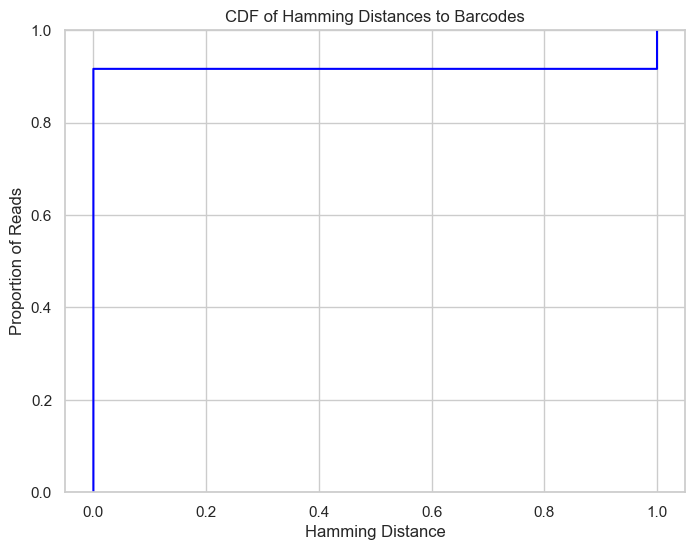

In [16]:
# plot the distances as a CDF
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
# Extract distances from the list of tuples
distances_only = [dist for _, dist in distances if dist != -1]

sns.ecdfplot(distances_only, stat="proportion", color="blue")
plt.xlabel("Hamming Distance")
plt.ylabel("Proportion of Reads")
plt.title("CDF of Hamming Distances to Barcodes")


In [ ]:
# extract reads aligned to ref region
for contig, (start, end) in contig_pos_dict.items():
    output_bam = out_dir / f"{contig}_extracted.bam"
    extract_reads_aligned_to_ref_region(bam, contig, start, end, output_bam)
    print(f"Extracted reads for {contig} to {output_bam}")
    # sort and index new bam file
    sorted_bam = out_dir / f"{contig}_extracted_sorted.bam"
    subprocess.run(["samtools", "sort", "-o", sorted_bam, output_bam])
    subprocess.run(["samtools", "index", sorted_bam])
    print(f"Sorted and indexed {sorted_bam}")

# # merge all the sorted bam files
# sorted_bam_files = list(out_dir.glob("*_extracted_sorted.bam"))
# merged_bam = out_dir / "filtered.bam"
# subprocess.run(["samtools", "merge", merged_bam] + [str(bam) for bam in sorted_bam_files])
# subprocess.run(["samtools", "index", merged_bam])
# print(f"Merged sorted BAM files into {merged_bam}")
    

Extracted reads to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_untranslatable_extracted.bam
Extracted reads for nanoluc_untranslatable to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_untranslatable_extracted.bam
Sorted and indexed /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_untranslatable_extracted_sorted.bam
Extracted reads to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_translatable_extracted.bam
Extracted reads for nanoluc_translatable to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_translatable_extracted.bam
Sorted and indexed /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/nanoluc_translatable_extracted_sorted.bam
Extracted reads to /data16/liam/working/data/alignments/250414_JANP-107_LT/hamming_dist_testing/short_nanoluc_untranslatable_extracted.bam
Ext

In [23]:
# compute hamming distance of each barcode against every other barcode
barcode_dict = {}
for name, seq in barcodes.items():
    barcode_dict[name] = {}
    for name2, seq2 in barcodes.items():
        dist = hamming_distance(seq, seq2)
        barcode_dict[name][name2] = dist


ic: 2025-04-17 16:04:48 | > barcode_df:      bc1  bc2  bc3  bc4  bc5  bc6
                                        bc1    0    4    4    3    3    3
                                        bc2    4    0    3    3    4    4
                                        bc3    4    3    0    4    4    3
                                        bc4    3    3    4    0    3    3
                                        bc5    3    4    4    3    0    4
                                        bc6    3    4    3    3    4    0
/home/liam/.local/lib/python3.11/site-packages/seaborn/matrix.py:256: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


Text(47.25, 0.5, 'Barcodes')

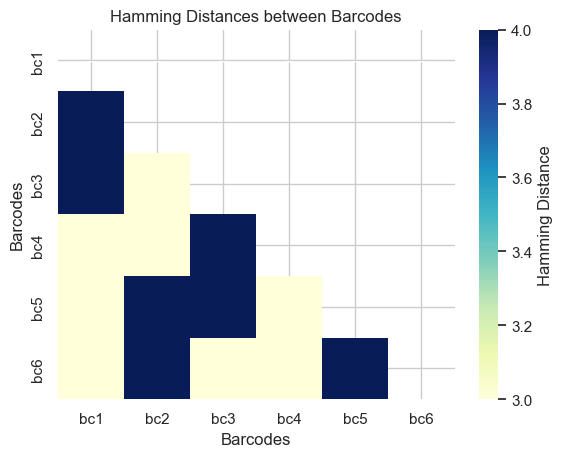

In [31]:
# print the barcode dictionary as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a DataFrame from the barcode dictionary
barcode_df = pd.DataFrame(barcode_dict).fillna(0)
# order the DataFrame by the barcode names
barcode_df = barcode_df.reindex(sorted(barcode_df.columns), axis=1)
# Set the index to the barcode names
barcode_df.index = barcode_df.columns
ic(barcode_df)
# # Create a mask for the upper triangle
mask = np.triu(np.ones_like(barcode_df, dtype=bool))
# Set the diagonal to NaN
np.fill_diagonal(mask, np.nan)
# # Create a heatmap
# plt.figure(figsize=(6, 6))
sns.heatmap(barcode_df, annot=True, fmt=".1f", mask=mask, cmap="YlGnBu", cbar_kws={"label": "Hamming Distance"})
plt.title("Hamming Distances between Barcodes")
plt.xlabel("Barcodes")
plt.ylabel("Barcodes")
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()
